In [1]:
import pandas as pd
df = pd.read_csv("/Users/ayeshashimu/Desktop/feedback-intelligence/chatgpt_reviews.csv")
print(df.shape)
df.head()

(2292, 4)


,date,title,review,rating
0,2023-05-21 16:42:24,Much more accessible for blind users than the ...,Up to this point I’ve mostly been using ChatGP...,4
1,2023-07-11 12:24:19,"Much anticipated, wasn’t let down.",I’ve been a user since it’s initial roll out a...,4
2,2023-05-19 10:16:22,"Almost 5 stars, but… no search function",This app would almost be perfect if it wasn’t ...,4
3,2023-05-27 21:57:27,"4.5 stars, here’s why","I recently downloaded the app and overall, it'...",4
4,2023-06-09 07:49:36,"Good, but Siri support would take it to the ne...",I appreciate the devs implementing Siri suppor...,4


In [2]:
print("missing per column:")
print(df.isnull().sum())
print("\nduplicate reviews:", df["review"].duplicated().sum())
print("\nrating distribution:")
print(df["rating"].value_counts().sort_index())

missing per column:
date      0
title     0
review    0
rating    0
dtype: int64

duplicate reviews: 35

rating distribution:
rating
1     495
2     139
3     220
4     304
5    1134
Name: count, dtype: int64


In [3]:
df = df.drop_duplicates(subset="review").reset_index(drop=True)
print("after dedupe:", df.shape)

df["length"] = df["review"].str.len()
print(df["length"].describe())

after dedupe: (2257, 4)
count    2257.000000
mean      209.399202
std       373.023328
min         1.000000
25%        39.000000
50%        95.000000
75%       214.000000
max      3182.000000
Name: length, dtype: float64


In [4]:
df = df[df["length"] >= 20].reset_index(drop=True)
print("after removing tiny reviews:", df.shape)

after removing tiny reviews: (1940, 5)


In [5]:
%pip install sentence-transformers


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(df["review"].tolist(), show_progress_bar=True)
print(embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

(1940, 384)


In [7]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
df["theme"] = kmeans.fit_predict(embeddings)
print(df["theme"].value_counts().sort_index())

theme
0     97
1    391
2    294
3    417
4     97
5    140
6    109
7    395
Name: count, dtype: int64


In [8]:
for t in range(8):
    count = (df["theme"] == t).sum()
    print(f"\n===== THEME {t}  (n={count}) =====")
    for s in df[df["theme"] == t]["review"].head(3).tolist():
        print("-", s[:200])


===== THEME 0  (n=97) =====
- I'm also a visually impaired user who relies on the VoiceOver screen reader built into iOS.
I'm generally impressed by the level of accessibility compared to the OpenAI website, but there's one area w
- I’ve been using the open AI website for many months now, and have introduced GPT to many if my friends and really spread it to a lot of people. I feel that this app is a bit step. It makes this amazin
- This app has won me over with its sleek design and user-friendly interface, not to mention the seamless integration of OpenAI into an iOS application. It's on the brink of earning a five-star rating f

===== THEME 1  (n=391) =====
- No doubt, this technology is absolutely life-changing, especially for me. You don’t know how thankful I am. However, I’m not reviewing the underlying technology, I’m reviewing its implementation on iO
- The OpenAI iOS App is a fantastic tool for anyone interested in artificial intelligence and machine learning. The app is well-d

In [9]:
theme_summary = df.groupby("theme").agg(
    count=("review", "size"),
    avg_rating=("rating", "mean")
).sort_values("avg_rating")
print(theme_summary)

       count  avg_rating
theme                   
2        294    1.656463
4         97    2.876289
0         97    3.329897
5        140    3.507143
6        109    3.678899
7        395    3.807595
3        417    4.179856
1        391    4.184143


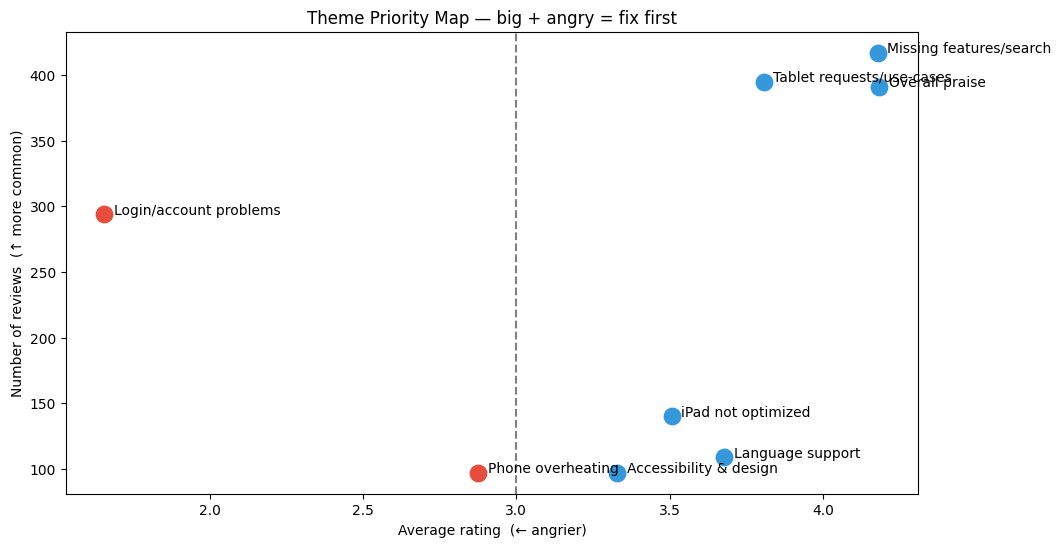

In [10]:
import matplotlib.pyplot as plt

names = {0:"Accessibility & design", 1:"Overall praise", 2:"Login/account problems",
         3:"Missing features/search", 4:"Phone overheating", 5:"iPad not optimized",
         6:"Language support", 7:"Tablet requests/use-cases"}

plt.figure(figsize=(11, 6))
for t, row in theme_summary.iterrows():
    plt.scatter(row["avg_rating"], row["count"], s=140, color="#e74c3c" if row["avg_rating"] < 3 else "#3498db")
    plt.annotate(names[t], (row["avg_rating"]+0.03, row["count"]))
plt.axvline(3, color="grey", linestyle="--")
plt.xlabel("Average rating  (← angrier)")
plt.ylabel("Number of reviews  (↑ more common)")
plt.title("Theme Priority Map — big + angry = fix first")
plt.show()

In [11]:
from sklearn.metrics import silhouette_score
sil = silhouette_score(embeddings, df["theme"])
print("Silhouette score:", round(sil, 3))

Silhouette score: 0.063


In [12]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].min(), "to", df["date"].max())
print("span days:", (df["date"].max() - df["date"].min()).days)

2023-05-18 15:43:36 to 2023-07-25 01:25:35
span days: 67


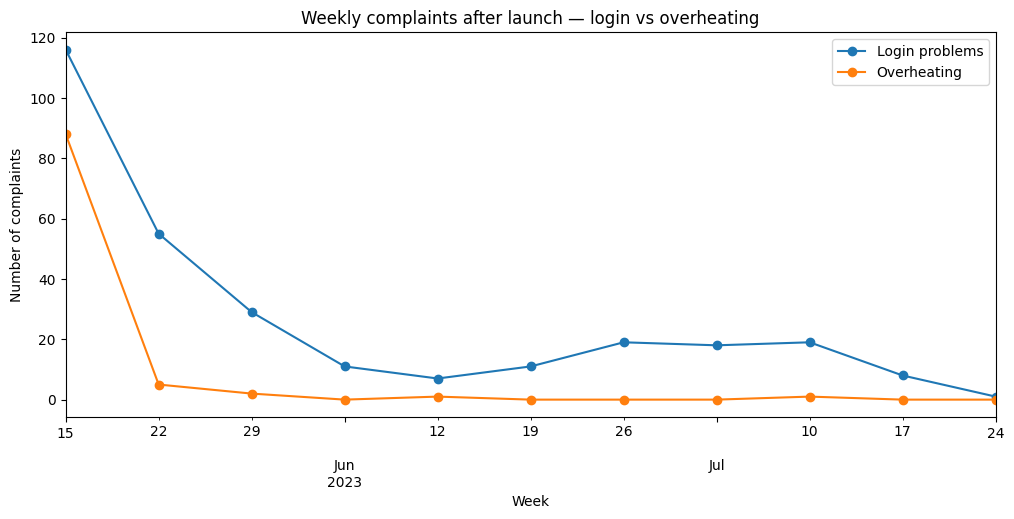

In [13]:
df["week"] = df["date"].dt.to_period("W").dt.start_time

pain = df[df["theme"].isin([2, 4])]
trend = pain.groupby(["week", "theme"]).size().unstack(fill_value=0)
trend.columns = ["Login problems", "Overheating"]

trend.plot(figsize=(12, 5), marker="o")
plt.title("Weekly complaints after launch — login vs overheating")
plt.ylabel("Number of complaints")
plt.xlabel("Week")
plt.show()

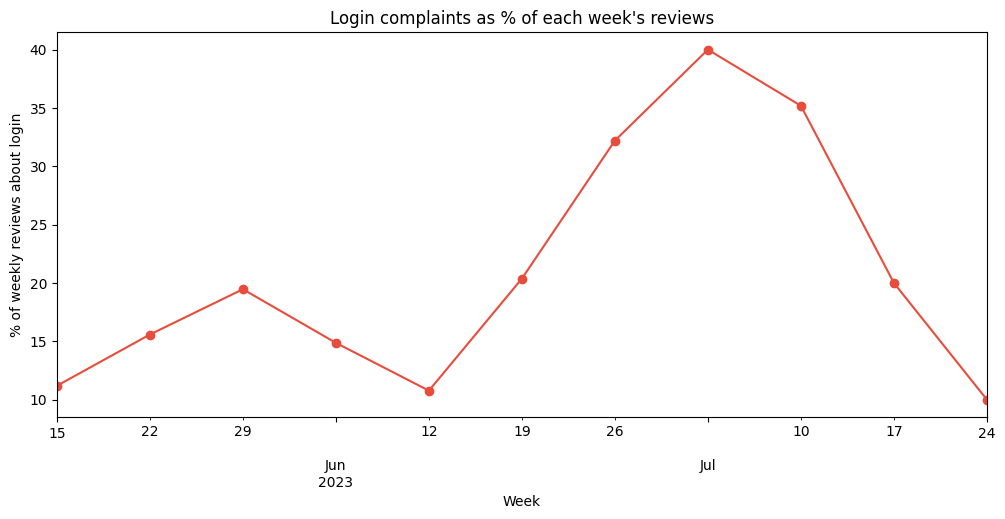

In [14]:
weekly_total = df.groupby("week").size()
login_share = (df[df["theme"] == 2].groupby("week").size() / weekly_total * 100).fillna(0)

login_share.plot(figsize=(12, 5), marker="o", color="#e74c3c")
plt.title("Login complaints as % of each week's reviews")
plt.ylabel("% of weekly reviews about login")
plt.xlabel("Week")
plt.show()

In [15]:
%pip install bertopic


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
from bertopic import BERTopic

topic_model = BERTopic(verbose=True)
topics, probs = topic_model.fit_transform(df["review"].tolist(), embeddings=embeddings)

topic_model.get_topic_info()

2026-07-13 18:25:55,092 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-13 18:26:02,057 - BERTopic - Dimensionality - Completed ✓
2026-07-13 18:26:02,057 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-13 18:26:02,087 - BERTopic - Cluster - Completed ✓
2026-07-13 18:26:02,089 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-13 18:26:02,131 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,374,-1_to_the_it_and,"[to, the, it, and, this, is, in, app, you, for]",[There’s been times of apps touting they are c...
1,0,235,0_app_this_the_and,"[app, this, the, and, it, to, its, is, for, very]",[I’m a young writer and sometimes I’m not extr...
2,1,130,1_ipad_version_screen_please,"[ipad, version, screen, please, on, iphone, th...","[Please make an iPad version., Make a version ..."
3,2,109,2_hot_phone_iphone_battery,"[hot, phone, iphone, battery, my, using, gets,...","[Phone gets very hot?!?, My phone gets so hot ..."
4,3,102,3_and_of_chatgpt_the,"[and, of, chatgpt, the, its, ai, to, with, an,...",[The ChatGPT iOS app has revolutionized the wa...
5,4,100,4_chatgpt_app_the_is,"[chatgpt, app, the, is, to, for, web, it, on, so]","[I know they just released this app, but the a..."
6,5,83,5_email_log_account_sign,"[email, log, account, sign, login, in, my, err...",[The website for chatgpt works perfectly fine ...
7,6,81,6_chatgptchatgpt_khng_20219_chatgpt,"[chatgptchatgpt, khng, 20219, chatgpt, thp, ch...",[I hope to join the simplified Chinese languag...
8,7,76,7_number_phone_my_you,"[number, phone, my, you, verification, email, ...",[I thought with the ChatGPT app you wouldn’t n...
9,8,66,8_gpt4_gpt_tv_gpt3,"[gpt4, gpt, tv, gpt3, to, it, on, the, web, plus]","[Although I’m a paid user, there’s no GPT-4 fu..."


In [17]:
df["btopic"] = topics
info = topic_model.get_topic_info().set_index("Topic")

btsummary = df[df["btopic"] != -1].groupby("btopic").agg(
    count=("review", "size"),
    avg_rating=("rating", "mean")
)
btsummary["label"] = info.loc[btsummary.index, "Name"]
print(btsummary.sort_values("avg_rating").head(12))

        count  avg_rating                                       label
btopic                                                               
7          76    1.394737                       7_number_phone_my_you
5          83    1.530120                    5_email_log_account_sign
22         21    1.761905                      22_birthday_date_to_my
10         53    1.792453                  10_screen_stuck_it_freezes
25         14    2.071429  25_request_invalid_cfdetailsthis_cfdetails
23         20    2.150000               23_countries_blocked_not_work
19         24    2.875000     19_2021_knowledge_september_information
2         109    2.926606                  2_hot_phone_iphone_battery
8          66    3.287879                          8_gpt4_gpt_tv_gpt3
14         42    3.428571                      14_history_the_to_copy
1         130    3.476923                1_ipad_version_screen_please
26         12    3.500000             26_limit_questions_question_ask


In [18]:
%pip install groq


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
from groq import Groq

client = Groq(api_key=""YOUR_KEY_HERE"")   
top = btsummary.sort_values("avg_rating").head(8)
evidence = "\n".join(
    f"- keywords [{row['label']}]: {int(row['count'])} reviews, avg rating {row['avg_rating']:.2f}/5"
    for _, row in top.iterrows()
)

prompt = f"""You are a product analyst. Using ONLY the data below (from ChatGPT iOS app reviews),
do two things:
1. Give each theme a short, clear human-readable NAME (based on the keywords).
2. Write a PRIORITIZED list of business recommendations. Tie each one to the numbers
   (review count and average rating). Be specific and concise.

Data (theme keywords : review count : average star rating out of 5):
{evidence}
"""

resp = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[{"role": "user", "content": prompt}],
)
print(resp.choices[0].message.content)

**Theme Names:**
1. Phone Number Issues
2. Login/Account Problems
3. Birthday/Date Errors
4. Screen Freezing
5. Invalid Request Errors
6. Country Blocking
7. Outdated Knowledge
8. iPhone Battery Drain

**Prioritized Business Recommendations:**
1. **Fix Phone Number Issues**: Address the 76 reviews (avg rating 1.39/5) by resolving phone number-related problems to improve user experience and increase ratings.
2. **Improve Login/Account Functionality**: Resolve the 83 reviews (avg rating 1.53/5) by streamlining the login and account sign-in process to reduce frustration and boost ratings.
3. **Optimize iPhone Performance**: Tackle the 109 reviews (avg rating 2.93/5) regarding iPhone battery drain by optimizing the app's performance to prevent battery issues and enhance user satisfaction.
4. **Solve Screen Freezing Issues**: Fix the 53 reviews (avg rating 1.79/5) by identifying and resolving the causes of screen freezing to provide a smoother user experience.
5. **Enhance Geographical Comp

## 📋 Recommendations (prioritized)

### 🔴 P0 — Fix now (high volume + lowest ratings)

**1. Account & login flow** — *169 reviews · 1.53★ · the #1 driver of 1-star reviews*
Complaints center on phone-number / email verification and Google sign-in loops. Login
complaints spiked to **~40% of weekly reviews in early July** — a sharp rise that points to a
**regression from a late-June release**. *Action:* audit the auth flow end-to-end, investigate
the late-June build for a verification bug, and add error logging on the sign-in path.

**2. App freezing / stuck screen** — *50 reviews · 1.74★*
A distinct crash (separate from login): the app hangs on the first screen. *Action:* reproduce
on affected devices/OS versions, add a timeout + retry, and instrument crash reporting.

### 🟠 P1 — Quick wins (small volume, very low ratings → cheap to fix, fast rating lift)

**3. Birthdate entry bug** — *22 reviews · 1.73★* — date field displays/saves incorrectly. Likely a
localization/format bug; low effort, high satisfaction return.

**4. "Invalid request" error** — *19 reviews · 2.21★* — a specific, reproducible API error users hit.
*Action:* trace the failing request and surface a clearer message.

**5. Overheating / battery drain** — *109 reviews · 2.93★* — large volume; users report the phone
"cooking." *Action:* profile CPU/animation/haptics usage (several users blamed haptics).

### 🟢 P2 — Roadmap (happy users, clear demand)

**6. iPad-optimized version** — *129 reviews · 3.48★ · the most-requested feature.* Users want the
desktop-style layout (chat + collapsible history). Highest-demand growth opportunity.

**7. Voice/Siri, plugins/browsing, chat history-search** — recurring feature asks from satisfied users.

### 🎯 Executive takeaway
> Users love ChatGPT's core value. Two bugs are capping the rating — **login (worsening after a
> July release)** and an **app-freezing crash** — fix those first. The birthdate and invalid-request
> bugs are cheap quick wins. Ship an **iPad version** to capture the biggest feature request.

In [21]:
import joblib
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
df["theme"] = kmeans.fit_predict(embeddings)

names = {0:"Accessibility & design", 1:"Overall praise", 2:"Login / account problems",
         3:"Missing features / search", 4:"Phone overheating", 5:"iPad not optimized",
         6:"Language support", 7:"Tablet requests / use-cases"}

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(names, "theme_names.pkl")
df[["date", "review", "rating", "theme"]].to_csv("reviews_analyzed.csv", index=False)
print("Saved: kmeans_model.pkl, theme_names.pkl, reviews_analyzed.csv")

Saved: kmeans_model.pkl, theme_names.pkl, reviews_analyzed.csv


2026-07-13 18:47:04.973 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 18:47:04.974 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-13 18:47:04.975 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-13 18:47:04.976 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 18:47:04.996 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 18:47:05.042 
  command:

    streamlit run /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-07-13

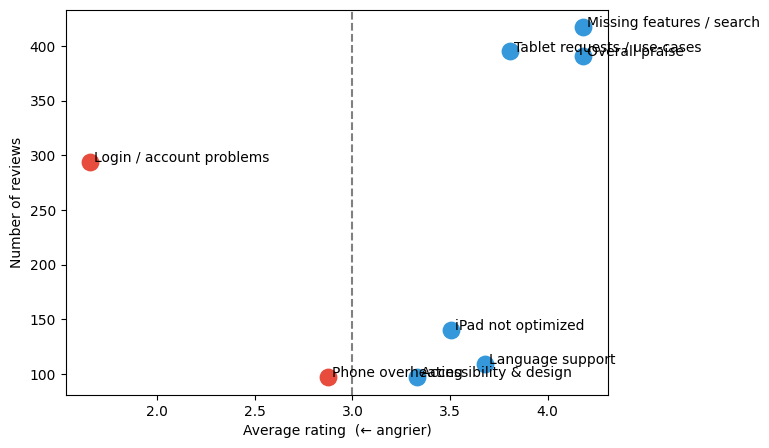

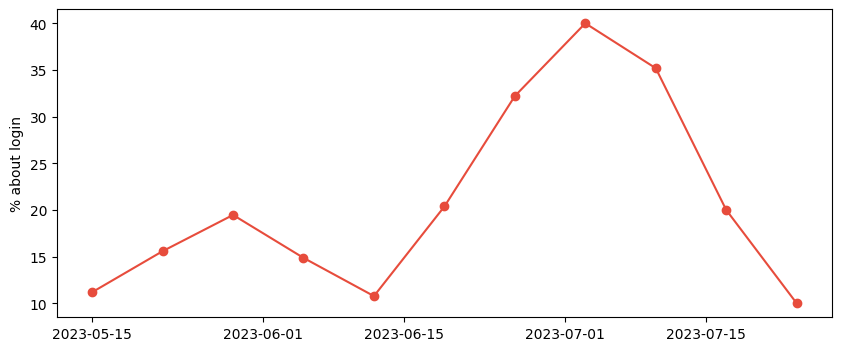

In [22]:
import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt

st.set_page_config(page_title="Feedback Intelligence", layout="wide")

@st.cache_data
def load_data():
    d = pd.read_csv("reviews_analyzed.csv")
    d["date"] = pd.to_datetime(d["date"])
    return d

@st.cache_resource
def load_embedder():
    from sentence_transformers import SentenceTransformer
    return SentenceTransformer("all-MiniLM-L6-v2")

names = joblib.load("theme_names.pkl")
kmeans = joblib.load("kmeans_model.pkl")
df = load_data()

st.title("📱 Customer Feedback Intelligence")
st.write("Turning 1,940 real ChatGPT app reviews into prioritized product insights.")

summary = df.groupby("theme").agg(count=("review", "size"), avg_rating=("rating", "mean"))
summary["theme_name"] = summary.index.map(names)
summary = summary.sort_values("avg_rating")

c1, c2 = st.columns(2)
with c1:
    st.subheader("Theme priority map")
    fig, ax = plt.subplots(figsize=(7, 5))
    for t, row in summary.iterrows():
        ax.scatter(row["avg_rating"], row["count"], s=140,
                   color="#e74c3c" if row["avg_rating"] < 3 else "#3498db")
        ax.annotate(names[t], (row["avg_rating"] + 0.02, row["count"]))
    ax.axvline(3, color="grey", linestyle="--")
    ax.set_xlabel("Average rating  (\u2190 angrier)")
    ax.set_ylabel("Number of reviews")
    st.pyplot(fig)
with c2:
    st.subheader("Themes by rating")
    st.dataframe(summary[["theme_name", "count", "avg_rating"]].round(2))

st.subheader("Login complaints over time (% of weekly reviews)")
df["week"] = df["date"].dt.to_period("W").dt.start_time
weekly_total = df.groupby("week").size()
login_share = (df[df["theme"] == 2].groupby("week").size() / weekly_total * 100).fillna(0)
fig2, ax2 = plt.subplots(figsize=(10, 4))
ax2.plot(login_share.index, login_share.values, marker="o", color="#e74c3c")
ax2.set_ylabel("% about login")
st.pyplot(fig2)

st.subheader("📋 Top recommendations")
st.markdown("""
1. **Account & login** (169 reviews, 1.53★) — #1 fix; spiked to ~40% of reviews in July (likely a release regression).
2. **App freezing / stuck screen** (50, 1.74★) — a distinct crash bug.
3. **Overheating / battery** (109, 2.93★) — high volume.
4. **Quick wins:** birthdate bug, invalid-request error.
5. **Roadmap:** iPad-optimized version (most-requested feature).
""")

st.subheader("🔎 Classify your own review")
user_text = st.text_area("Paste a review and see which theme it matches:")
if st.button("Analyze") and user_text.strip():
    emb = load_embedder().encode([user_text])
    theme = int(kmeans.predict(emb)[0])
    st.success(f"This review falls under: **{names[theme]}**")

In [23]:
import joblib
folder = "/Users/ayeshashimu/Desktop/feedback-intelligence/"
joblib.dump(kmeans, folder + "kmeans_model.pkl")
joblib.dump(names, folder + "theme_names.pkl")
df[["date", "review", "rating", "theme"]].to_csv(folder + "reviews_analyzed.csv", index=False)
print("Saved into feedback-intelligence folder")

Saved into feedback-intelligence folder
